<a href="https://colab.research.google.com/github/tgp989/fintech-credit-segmentation/blob/main/Reto_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integración Multidimensional - Sector Fintech

En este espacio de trabajo se plantea como caso de estudio un proceso de **integración multidimensional de datos aplicado a una entidad del sector fintech**, con el objetivo de optimizar la asignación de créditos a sus solicitantes.

La entidad financiera busca **reducir el número de sucursales encargadas de evaluar a los solicitantes de crédito**, para lo cual propone llevar a cabo un proceso de integración de datos que permita consolidar la información en cinco nuevas sucursales, facilitando la toma de decisiones y mejorando la eficiencia operativa.

El proceso de análisis toma como base variables **numéricas**, entre las que se incluyen ingreso, egresos, monto solicitado, edad, hijos, personas a cargo, estrato, plazo y cuota del crédito. Estas variables permiten evaluar el perfil de cada solicitante y determinar tanto el número de clientes asignados a cada sucursal como su procedencia geográfica y su porcentaje de aprobación o rechazo de créditos.

En primer lugar, se realiza una **selección de una muestra aleatoria de cinco solicitantes**, que sirve como referencia inicial para el proceso de agrupamiento. Posteriormente, se aplica el método de **K-medois** con el fin de agrupar a los solicitantes en cinco clusters, representando así las nuevas sucursales de atención.

Adicionalmente, se utilizan **herramientas gráficas como gráficos de araña u otras representaciones multidimensionales**, con el objetivo de visualizar las características de cada cluster y facilitar la interpretación de los resultados obtenidos.

Finalmente, los resultados del proceso de integración multidimensional son presentados en una **página web o repositorio en GitHub**, permitiendo a la entidad financiera analizar la distribución de los solicitantes, comprender sus características y tomar decisiones estratégicas respecto a la asignación de créditos y la reorganización de sus sucursales.

Los datos utilizados para el desarrollo del caso corresponden a información de **solicitantes de crédito en dólares (USD) y su ubicación por municipios**, los cuales contienen las variables necesarias para realizar el proceso de segmentación, análisis e integración multidimensional.


0. Se procede con la carga de las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

import IPython.display as display
import base64 # Compresion de imagen
import requests # Conexion externa con el GitHub

Mounted at /content/drive


1. Se carga el archivo desde Google Drive

In [ ]:
nxl = '/content/drive/MyDrive/integración de datos y prospectiva/Reto 4/4. SolicitantesCrédito(USD)_Municipios.xlsx'
xls = pd.ExcelFile(nxl)

# Se procede con la integracion de todos los datos en una sola hoja
XDB=pd.DataFrame()

df=pd.read_excel(xls,sheet_name=0)
XDB=pd.concat([XDB,df],ignore_index=True)

# Ofuscamos los datos - random_state=42: Para que el modelo utilice siempre los mismos datos
XDB=XDB.sample(frac=1,random_state=42).reset_index(drop=True)
XDB=XDB.dropna()

2. Seleccion de variables clave

In [ ]:
variables = ['Edad','Hijos','Perscargo','Estrato','Ingresos','Egresos','Monto (EAD)','Plazo','Cuota (COP)']

4. Se crean las semillas de integracion

In [ ]:
from IPython.display import display

XC=np.array(XDB[variables].iloc[0:5]) # Semillas de integracion - Son los primeros 5 datos de la DB
XD=np.array(XDB[variables]) # Solo variables numericas
nc=np.zeros((len(XD),1))

# Se procede con la integracion
for k in range(len(XD)):
  Xind=XD[k,] # Clasifico el primer individuo - Por pertenencia
  m1=np.sum(((XC[:,]-Xind)/XC[:,])**2,axis=1)
  print(m1) # Aqui mostramos el individuo
  nc[k]=np.argmin(m1) # Clasificacion del individuo
  cluster=int(np.argmin(m1)) # Para que me lo muestre como un entero
  print(f'El individuo {k} pertenece al cluster:', cluster) # A que cluster pertenece
  XC[cluster,]=(XC[cluster,]+Xind)/2 # Aqui se hace la integracion de los datos

# Se muestran los clusters
dfxc=pd.DataFrame(XC)
dfxc.columns=variables
display(dfxc)


/tmp/ipykernel_7531/4170174973.py:10: RuntimeWarning: divide by zero encountered in divide
  m1=np.sum(((XC[:,]-Xind)/XC[:,])**2,axis=1)
/tmp/ipykernel_7531/4170174973.py:10: RuntimeWarning: invalid value encountered in divide
  m1=np.sum(((XC[:,]-Xind)/XC[:,])**2,axis=1)


Se truncaron las últimas líneas 5000 del resultado de transmisión.
 2.51084069e+58]
El individuo 4145 pertenece al cluster: 2
[7.01760821e+03            inf 3.00285093e+00 8.95871085e+02
 1.36238581e+02]
El individuo 4146 pertenece al cluster: 2
[2.74876904e+11            inf 9.27258913e+00 1.26765060e+30
 2.51084069e+58]
El individuo 4147 pertenece al cluster: 2
[3.70216647e+04            inf 5.69925319e+00 5.66033352e+03
 1.20774156e+03]
El individuo 4148 pertenece al cluster: 2
[2.74876951e+11            inf 1.57221683e+01 1.26765060e+30
 2.51084069e+58]
El individuo 4149 pertenece al cluster: 2
[1.09950968e+12            inf 7.67071930e+00 5.07060240e+30
 1.00433628e+59]
El individuo 4150 pertenece al cluster: 2
[8.24303868e+05            inf 1.99793835e+01 1.14590074e+05
 1.90576271e+04]
El individuo 4151 pertenece al cluster: 2
[2.74877041e+11            inf 1.55451716e+00 1.26765060e+30
 2.51084069e+58]
El individuo 4152 pertenece al cluster: 2
[2.74876860e+11            nan 4.7

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,39.232613,1.126234,2.384186e-07,3.405781,3.252298,2.632598,2.344912,30.657743,0.089552
1,27.279945,0.000000,1.567918e+00,2.162709,514.694714,532.482915,358.204906,20.819807,32.654453
2,36.549339,1.528809,5.906465e-01,2.247119,652.873930,610.344009,453.254060,47.838778,13.254378
3,39.278561,1.665140,5.551115e-17,2.369825,20.190248,19.617847,10.784324,43.798918,0.338021
4,38.416502,2.051601,6.018531e-36,2.226018,58.206159,48.286253,39.146776,25.857530,2.021030


Cluster de los cinco primeros datos de XDB

In [ ]:
XDB['Cluster'] = nc.flatten()
display(XDB.head())


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio,Cluster
0,6556,63,NR,Unión Libre,1,1,1,3,Bachiller,Ninguno,...,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.233305,474.284668,0.473965,94.814667,Caldas,0.0
1,239,31,Mujer,Soltero,0,1,1,2,Tecnólogo,Indefinido,...,Fondo de Garantia,Prop.sin Hipoteca,Con Experiencia sin Mora,0,0.254857,322.984283,0.386951,-59.363306,Caldas,1.0
2,226,61,NR,Casado,7,3,3,2,Tecnólogo,Indefinido,...,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.089151,619.955383,0.156131,175.430444,Sabaneta,2.0
3,8017,42,Mujer,Soltero,2,1,1,3,Tecnólogo,Fijo,...,Libranza Establecida,Sin Patrimonio,Una mora 60 Dìas,0,0.157716,486.018250,0.292610,265.696222,Caldas,3.0
4,3334,32,Mujer,Soltero,1,1,1,4,Bachiller,Indefinido,...,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.089574,517.180481,0.155736,406.870611,Itagüí,4.0


Estadisticas de las variables trabajadas por cluster

In [ ]:
cluster_stats = XDB.groupby('Cluster')[variables].agg(['mean', 'median', 'std'])
display(cluster_stats)

Edad                       Hijos                  Perscargo  \
              mean median        std      mean median       std      mean   
Cluster                                                                     
0.0      44.652174   43.0  13.496157  1.260870    1.0  0.448978  0.043478   
1.0      40.861552   41.0  11.933918  0.000000    0.0  0.000000  0.820547   
2.0      41.049452   41.0  12.397694  1.758365    1.0  1.136797  0.912644   
3.0      45.327273   46.0  12.280751  1.963636    2.0  1.216608  0.018182   
4.0      41.739496   42.0  12.598401  1.689076    1.0  1.079453  0.016807   

                           Estrato  ...     Egresos Monto (EAD)              \
        median       std      mean  ...         std        mean      median   
Cluster                             ...                                       
0.0        0.0  0.208514  2.565217  ...   50.123135   38.172443   15.803573   
1.0        1.0  0.998888  2.932099  ...  520.660335  537.654976  431.144313   
2.0        1.0  1.044228  2.909979  ...  494.985395  544.062479  431.114146   
3.0        0.0  0.134840  2.472727  ...  175.516508   98.211730   62.298131   
4.0        0.0  0.129090  2.932773  ...  555.235912  383.218458  188.189100   

                         Plazo                   Cuota (COP)             \
                std       mean median        std        mean     median   
Cluster                                                                   
0.0       48.199237  35.478261   36.0   8.468495    1.298212   0.572264   
1.0      443.243556  32.271164   36.0  12.810489   29.931197  18.020703   
2.0      444.812649  32.747705   36.0  12.726677   30.865488  17.802969   
3.0      110.187337  32.727273   36.0  10.634421    4.337404   2.486364   
4.0      424.677297  32.142857   36.0  12.070615   20.925808   9.356249   

                    
               std  
Cluster             
0.0       1.499586  
1.0      47.660005  
2.0      55.631626  
3.0       5.174956  
4.0      35.682110  

[5 rows x 27 columns]

5. Numero de clientes por cluster, porcentaje de preaprovacion/rechazo y municipios de donde proceden los solicitantes

In [ ]:
# Número de clientes por cluster
clientes_por_cluster = XDB.groupby('Cluster')['Cédula'].count()

display(clientes_por_cluster)

,Cédula
Cluster,
0.0,23
1.0,2268
2.0,3377
3.0,55
4.0,119


In [ ]:
# Conteo de municipios por cluster (cantidad)
conteo = XDB.groupby('Cluster')['Municipio'].value_counts()

# Porcentaje por cluster
porcentaje = XDB.groupby('Cluster')['Municipio'].value_counts(normalize=True) * 100

# Unir ambos resultados
municipios_info = pd.concat([conteo, porcentaje], axis=1)
municipios_info.columns = ['Cantidad', 'Porcentaje (%)']

# Redondear porcentaje
municipios_info['Porcentaje (%)'] = municipios_info['Porcentaje (%)'].round(2)

display(municipios_info)

Cantidad  Porcentaje (%)
Cluster Municipio                          
0.0     Caldas           21           91.30
        Itagüí            2            8.70
1.0     Caldas          716           31.57
        Sabaneta        688           30.34
        Bello           411           18.12
        Itagüí          243           10.71
        Medellín        184            8.11
        Envigado         26            1.15
2.0     Sabaneta       1092           32.34
        Caldas         1038           30.74
        Bello           621           18.39
        Itagüí          320            9.48
        Medellín        256            7.58
        Envigado         50            1.48
3.0     Caldas           48           87.27
        Itagüí            4            7.27
        Sabaneta          3            5.45
4.0     Caldas           55           46.22
        Sabaneta         21           17.65
        Itagüí           19           15.97
        Bello            15           12.61
        Medellín          8            6.72
        Envigado          1            0.84

In [ ]:
# Crear columna Decision
XDB['Decision'] = XDB.apply(
    lambda x: 'Preaprobado' if (x['Score'] > 400 and x['Prob.Default (PD)'] < 0.5) else 'Prenegado', #Se definió como preaprobado a aquellos solicitantes con un puntaje superior a 400 y una probabilidad de incumplimiento inferior al 50%, considerando un perfil de riesgo aceptable.
    axis=1
)

# Porcentajes por cluster
porcentajes_cluster = XDB.groupby('Cluster')['Decision'].value_counts(normalize=True).unstack() * 100

display(porcentajes_cluster)

Decision,Preaprobado,Prenegado
Cluster,,
0.0,21.739130,78.260870
1.0,64.065256,35.934744
2.0,69.410720,30.589280
3.0,16.363636,83.636364
4.0,47.058824,52.941176


6. Preparación y transformación de datos de clusters



In [ ]:
cluster_stats_mean = cluster_stats.loc[:, (slice(None), 'mean')].copy()
cluster_stats_mean.columns = cluster_stats_mean.columns.get_level_values(0) # Aplanar las columnas de índice múltiple
cluster_stats_mean = cluster_stats_mean.reset_index()
display(cluster_stats_mean)

,Cluster,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,0.0,44.652174,1.260870,0.043478,2.565217,54.800565,46.599488,38.172443,35.478261,1.298212
1,1.0,40.861552,0.000000,0.820547,2.932099,742.319034,663.725741,537.654976,32.271164,29.931197
2,2.0,41.049452,1.758365,0.912644,2.909979,737.654940,655.512326,544.062479,32.747705,30.865488
3,3.0,45.327273,1.963636,0.018182,2.472727,156.323095,146.890133,98.211730,32.727273,4.337404
4,4.0,41.739496,1.689076,0.016807,2.932773,517.252809,464.682695,383.218458,32.142857,20.925808


Normalizacion de variables numericas



In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Iniciar MinMaxScaler
scaler = MinMaxScaler()

# Excluir la columna de cluster
numerical_cols = cluster_stats_mean.columns.drop('Cluster')

# Escalar variables
scaled_data = pd.DataFrame(scaler.fit_transform(cluster_stats_mean[numerical_cols]), columns=numerical_cols)
scaled_data['Cluster'] = cluster_stats_mean['Cluster']

display(scaled_data.head())

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Cluster
0,0.848826,0.642110,0.029773,0.201045,0.000000,0.000000,0.000000,1.000000,0.000000,0.0
1,0.000000,0.000000,0.897194,0.998534,1.000000,1.000000,0.987334,0.038468,0.968401,1.0
2,0.042076,0.895464,1.000000,0.950453,0.993216,0.986691,1.000000,0.181342,1.000000,2.0
3,1.000000,1.000000,0.001535,0.000000,0.147665,0.162512,0.118681,0.175216,0.102789,3.0
4,0.196596,0.860177,0.000000,1.000000,0.672640,0.677468,0.682057,0.000000,0.663828,4.0


7. Perfiles de cluster



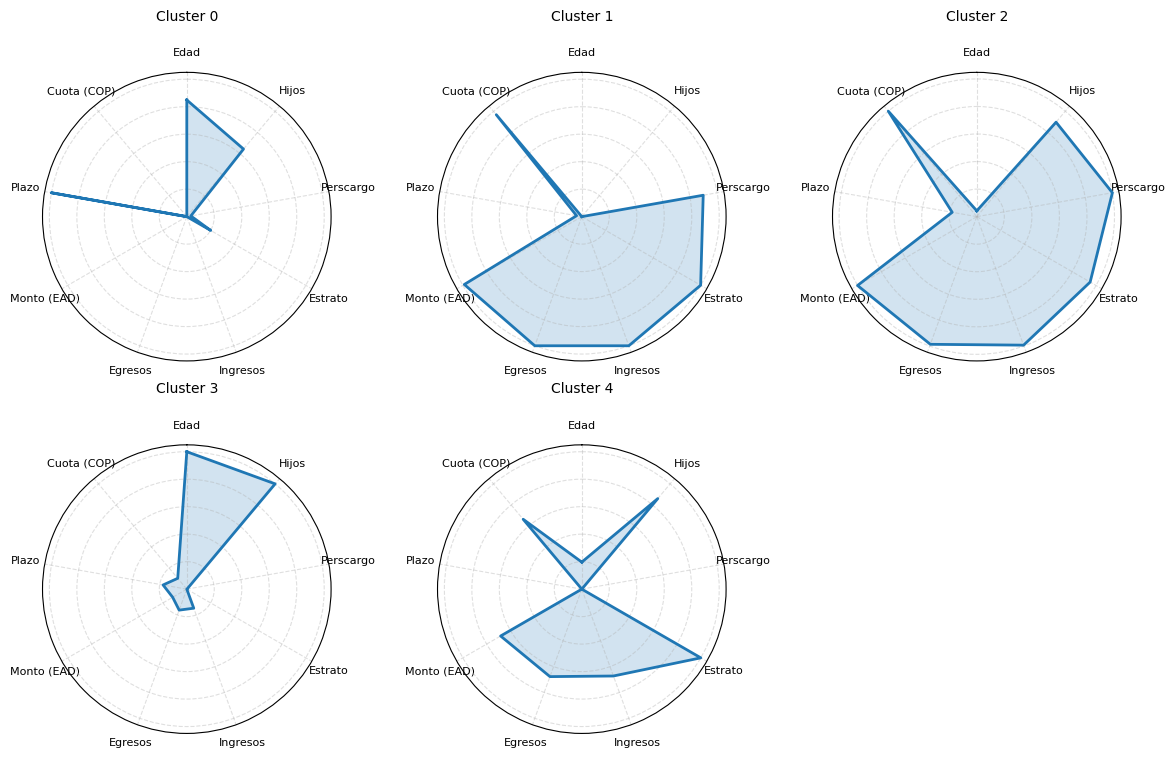

In [ ]:
# Preparación de datos
r_chart_data = scaled_data.set_index('Cluster')
categories = list(r_chart_data.columns)
num_vars = len(categories)

# Calcular ángulos
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # cerrar gráfico

# Crear figura
fig, axes = plt.subplots(figsize=(12, 8), nrows=2, ncols=3, subplot_kw=dict(polar=True))
axes = axes.flatten()

# Graficar cada cluster
for i, cluster_id in enumerate(r_chart_data.index.unique()):
    if i < len(axes):
        values = r_chart_data.loc[cluster_id].tolist()
        values += values[:1]

        ax = axes[i]

        # Línea principal (más gruesa)
        ax.plot(angles, values, linewidth=2)

        # Área con transparencia (más elegante)
        ax.fill(angles, values, alpha=0.2)

        # Ajustes de orientación
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)

        # Etiquetas más pequeñas (evita saturación)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=8)

        # Grid más suave
        ax.grid(True, linestyle='--', alpha=0.4)

        # Quitar etiquetas radiales innecesarias
        ax.set_yticklabels([])

        # Título más limpio
        ax.set_title(f'Cluster {int(cluster_id)}', fontsize=10, y=1.15)

# Ocultar gráficos vacíos (MEJOR que eliminarlos)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Ajuste de espacios
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Perfil.png")
plt.show()

8. Grafico de clientes por cluster


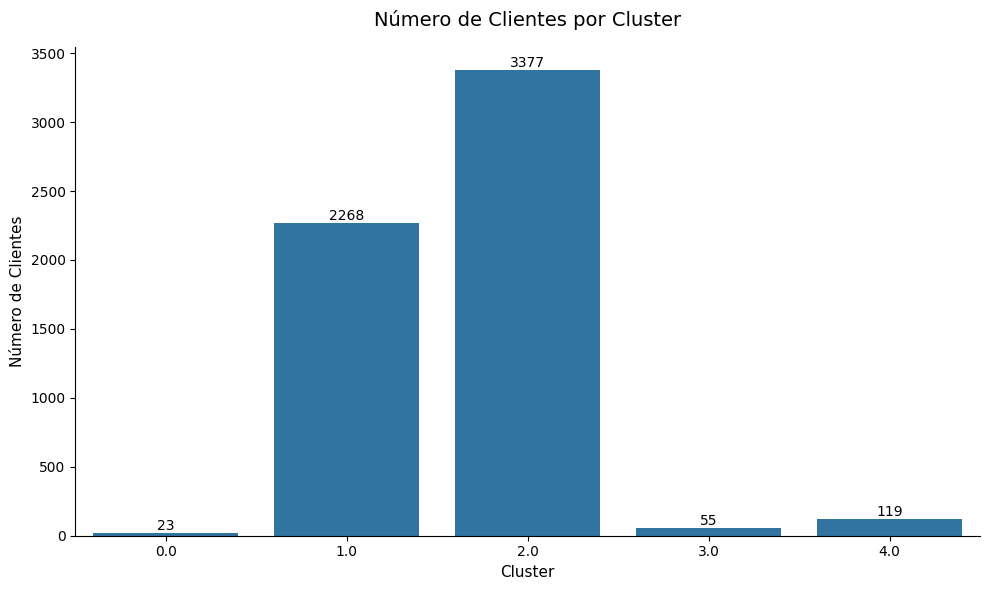

In [ ]:
plt.figure(figsize=(10, 6))

# Gráfico
ax = sns.barplot(
    x=clientes_por_cluster.index,
    y=clientes_por_cluster.values
)

# Títulos y etiquetas (más claros)
ax.set_title('Número de Clientes por Cluster', fontsize=14, pad=15)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Número de Clientes', fontsize=11)

# Quitar bordes innecesarios
sns.despine()

# Agregar valores encima de cada barra
for i, v in enumerate(clientes_por_cluster.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("Clientes.png")
plt.show()

9. Grafico de preaprobacion vs prenegacion



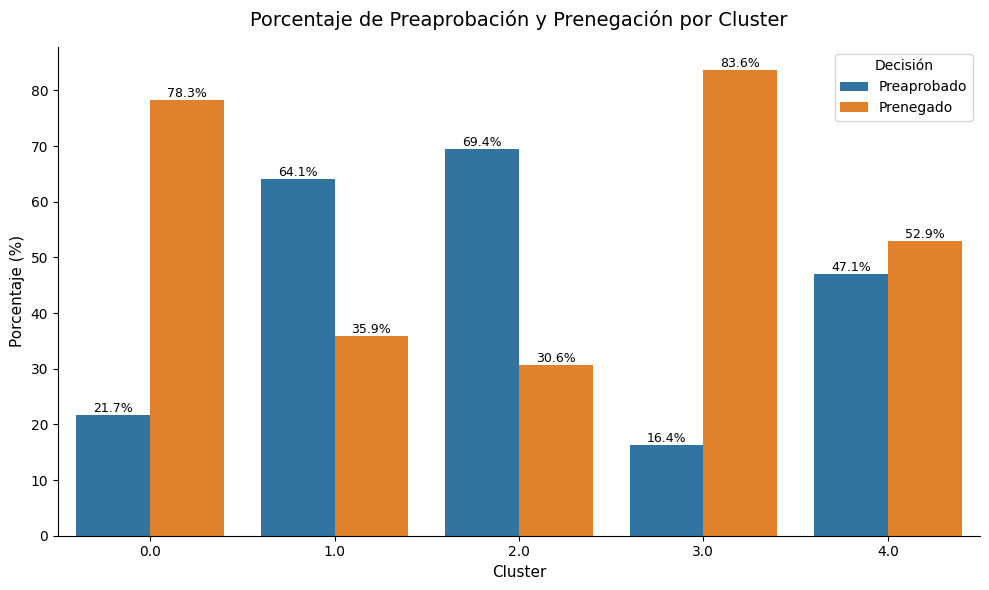

In [ ]:
# Preparar datos en formato largo (mejor para seaborn)
df_plot = porcentajes_cluster[['Preaprobado', 'Prenegado']].reset_index()
df_plot = df_plot.melt(id_vars='Cluster',
                       var_name='Decision',
                       value_name='Porcentaje')

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_plot,
    x='Cluster',
    y='Porcentaje',
    hue='Decision'
)

# Títulos
ax.set_title('Porcentaje de Preaprobación y Prenegación por Cluster', fontsize=14, pad=15)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Porcentaje (%)', fontsize=11)

# Quitar bordes
sns.despine()

# Agregar valores encima de barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.legend(title='Decisión')
plt.tight_layout()
plt.savefig("Decision.png")
plt.show()

10. Grafico de Municipios por cluster

In [ ]:
municipios_info_reset = municipios_info.reset_index()
municipios_per_cluster = municipios_info_reset.groupby('Cluster').apply(lambda x: x.nlargest(5, 'Cantidad')).reset_index(drop=True)
display(municipios_per_cluster)

/tmp/ipykernel_7531/3327486240.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  municipios_per_cluster = municipios_info_reset.groupby('Cluster').apply(lambda x: x.nlargest(5, 'Cantidad')).reset_index(drop=True)


,Cluster,Municipio,Cantidad,Porcentaje (%)
0,0.0,Caldas,21,91.30
1,0.0,Itagüí,2,8.70
2,1.0,Caldas,716,31.57
3,1.0,Sabaneta,688,30.34
4,1.0,Bello,411,18.12
5,1.0,Itagüí,243,10.71
6,1.0,Medellín,184,8.11
7,2.0,Sabaneta,1092,32.34
8,2.0,Caldas,1038,30.74
9,2.0,Bello,621,18.39


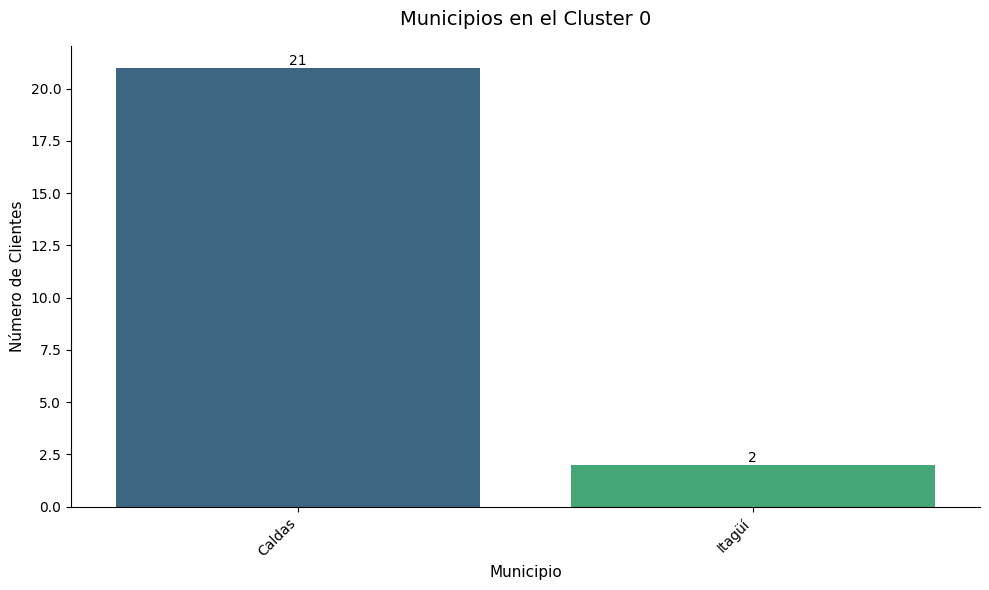

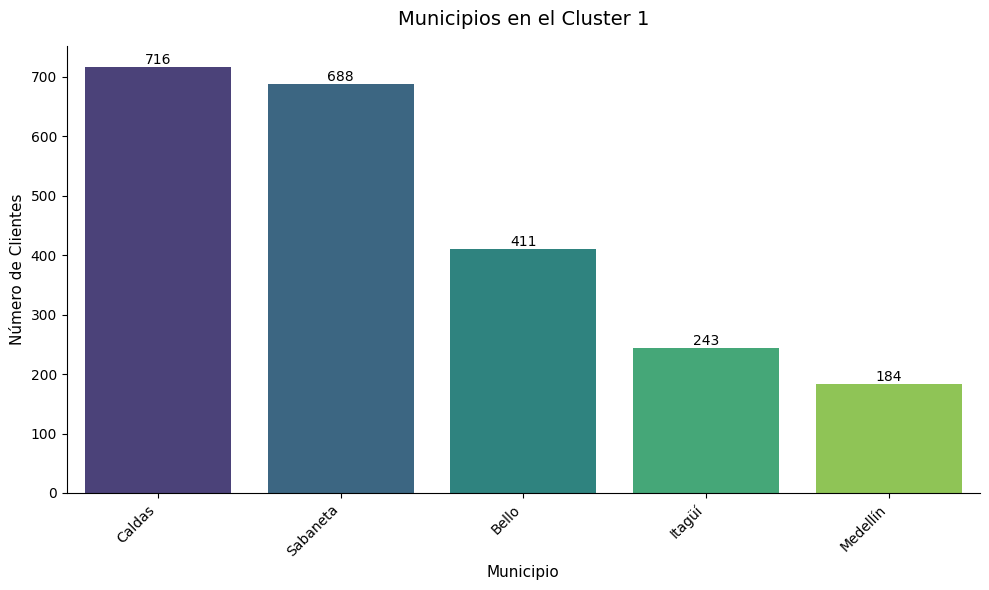

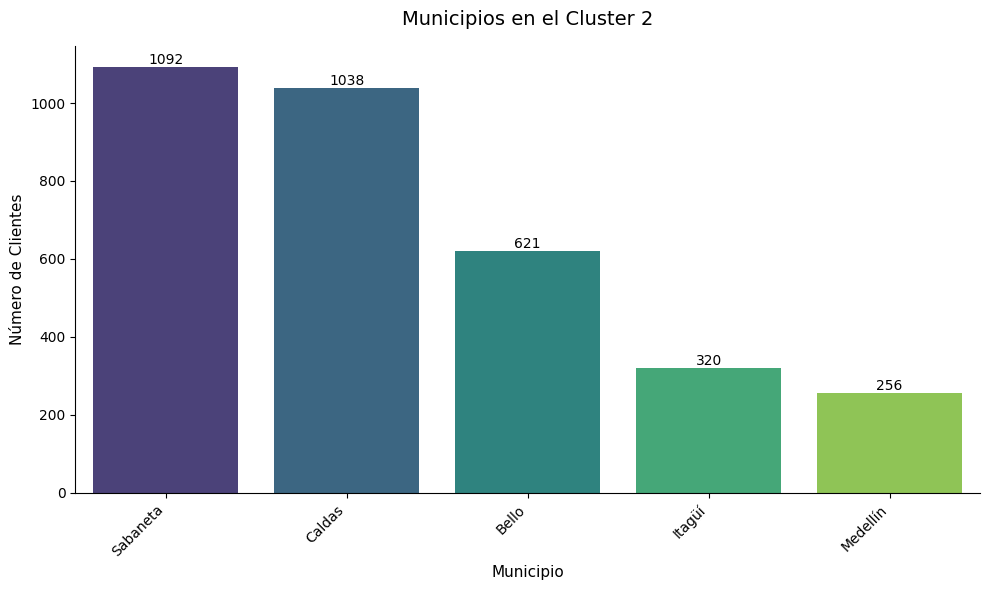

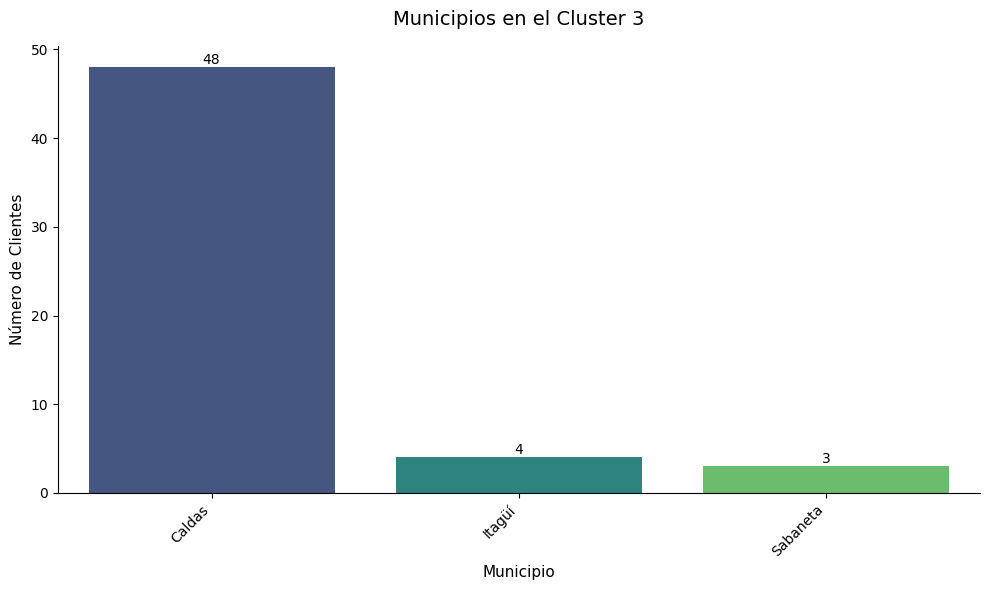

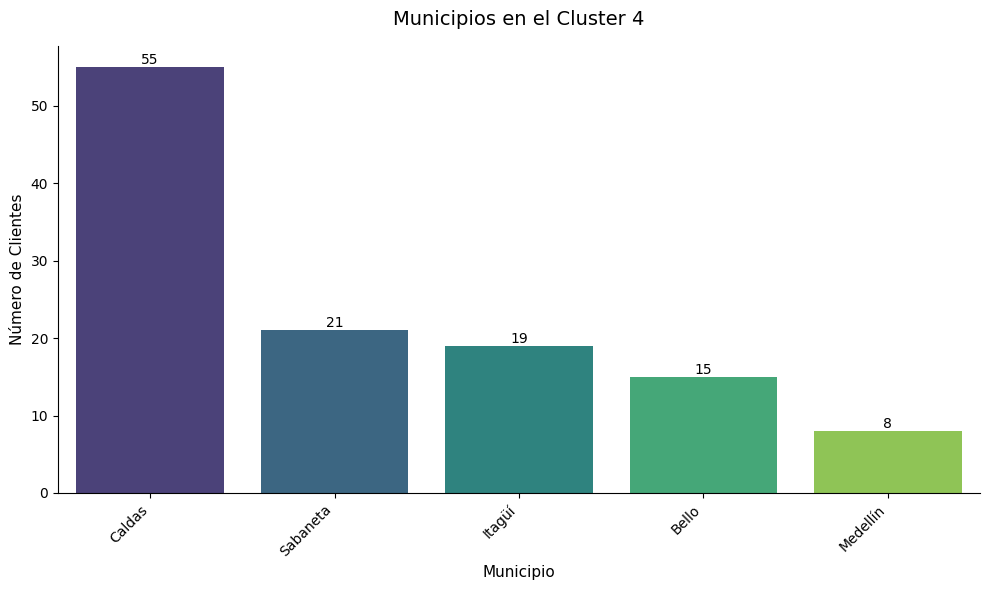

In [ ]:
for cluster_id in municipios_per_cluster['Cluster'].unique():
    cluster_data = municipios_per_cluster[municipios_per_cluster['Cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Municipio', y='Cantidad', data=cluster_data, hue='Municipio', legend=False, palette='viridis')

    ax.set_title(f'Municipios en el Cluster {int(cluster_id)}', fontsize=14, pad=15)
    ax.set_xlabel('Municipio', fontsize=11)
    ax.set_ylabel('Número de Clientes', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    sns.despine()

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'Municipios_Cluster_{int(cluster_id)}.png')
    plt.show()

# 🧾 Hallazgos Consolidados para la Presentación

## 📊 Descripción General de los Clusters para la Optimización de la Asignación de Créditos

Con el objetivo de optimizar la asignación de créditos y reducir el número de sucursales, se identificaron cinco clusters distintos de clientes. Cada cluster representa un segmento único de solicitantes con características demográficas, financieras y geográficas específicas, así como diferentes niveles de aprobación y rechazo de créditos.

---

## 🔹 Cluster 0

* Total de clientes: 23
* Procedencia geográfica predominante: Caldas
* Preaprobados: 21.74%
* Prenegados: 78.26%

---

## 🔹 Cluster 1

* Total de clientes: 2268
* Procedencia geográfica predominante: Caldas
* Preaprobados: 64.07%
* Prenegados: 35.93%

---

## 🔹 Cluster 2

* Total de clientes: 3377
* Procedencia geográfica predominante: Sabaneta
* Preaprobados: 69.41%
* Prenegados: 30.59%

---

## 🔹 Cluster 3

* Total de clientes: 55
* Procedencia geográfica predominante: Caldas
* Preaprobados: 16.36%
* Prenegados: 83.64%

---

## 🔹 Cluster 4

* Total de clientes: 119
* Procedencia geográfica predominante: Caldas
* Preaprobados: 47.06%
* Prenegados: 52.94%

11. Desplegar pagina web en local

✅ Página web creada correctamente


Cluster,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0.0,44.65,1.26,0.04,2.57,54.80,46.60,38.17,35.48,1.30
1.0,40.86,0.00,0.82,2.93,742.32,663.73,537.65,32.27,29.93
2.0,41.05,1.76,0.91,2.91,737.65,655.51,544.06,32.75,30.87
3.0,45.33,1.96,0.02,2.47,156.32,146.89,98.21,32.73,4.34
4.0,41.74,1.69,0.02,2.93,517.25,464.68,383.22,32.14,20.93

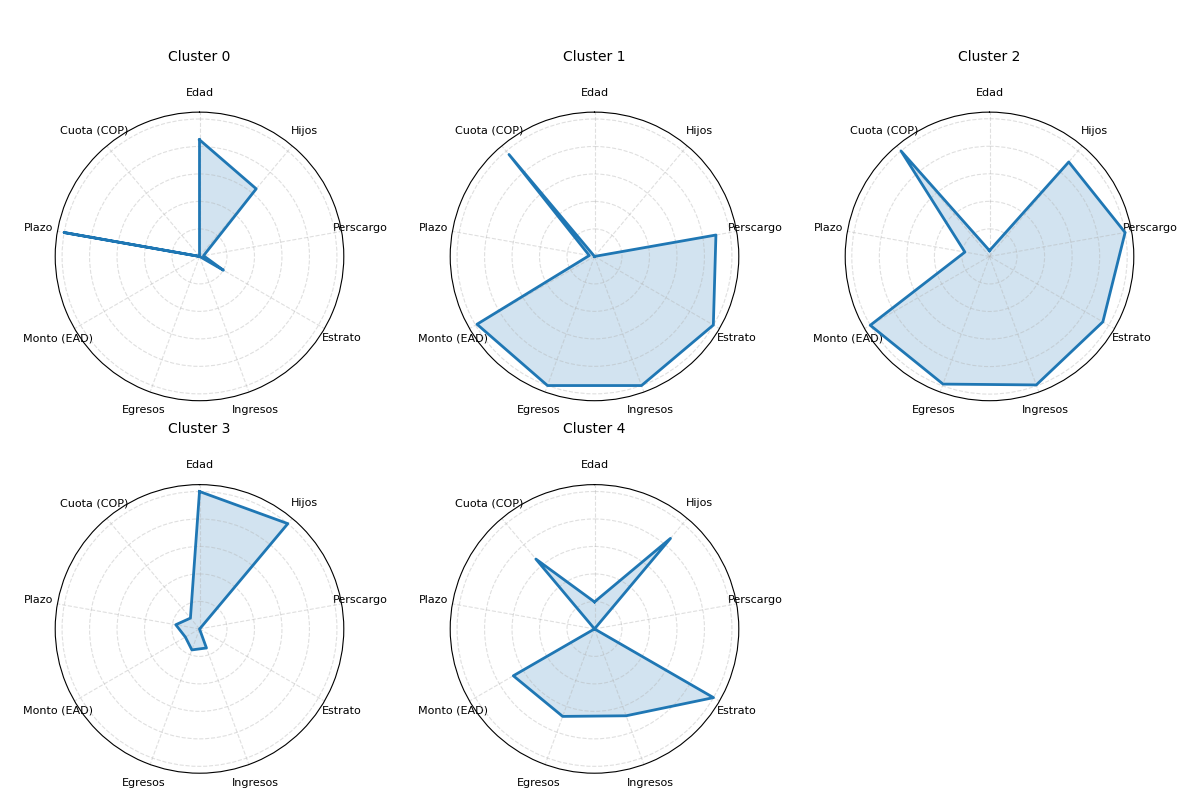
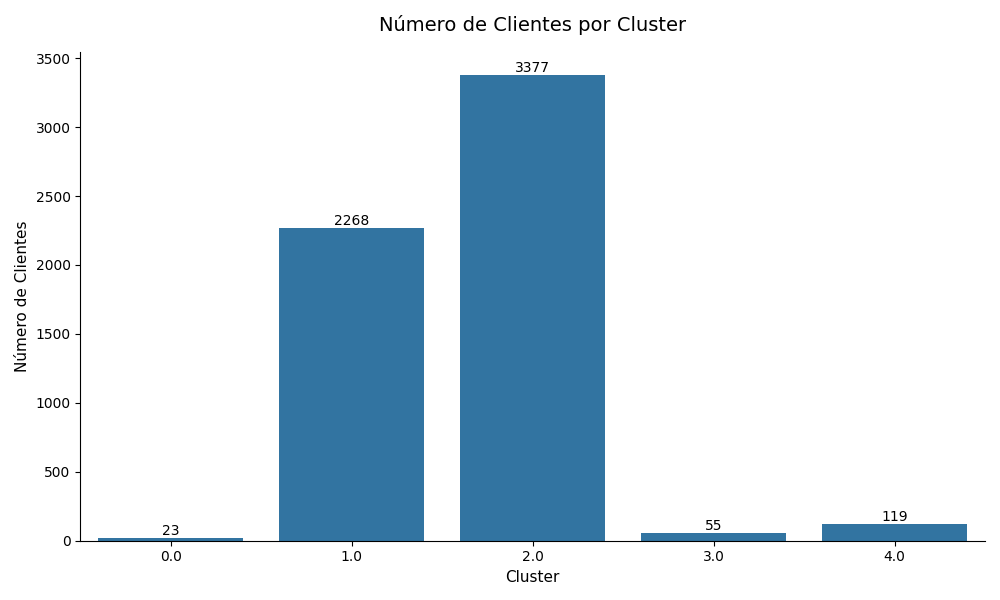
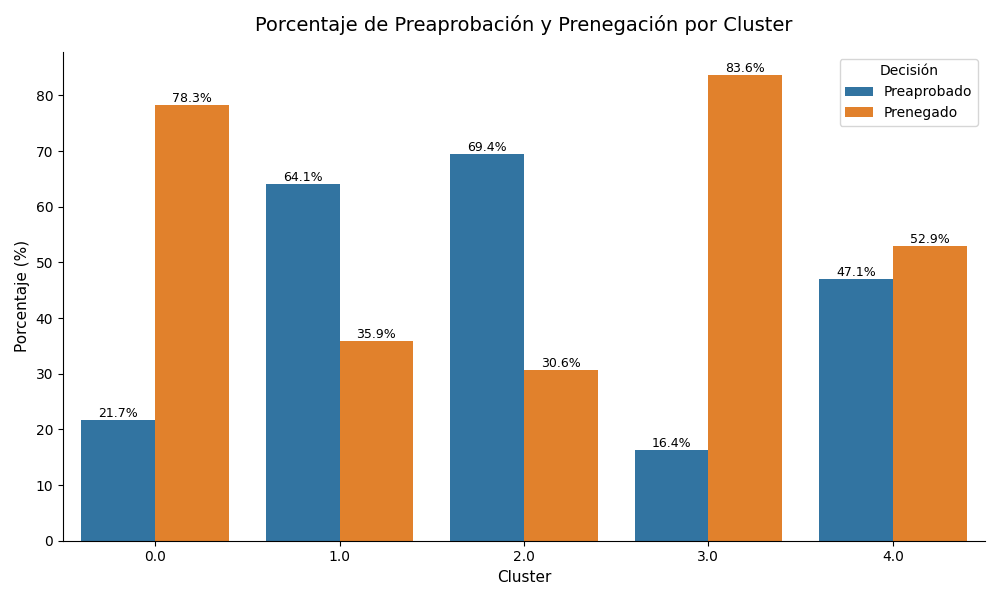
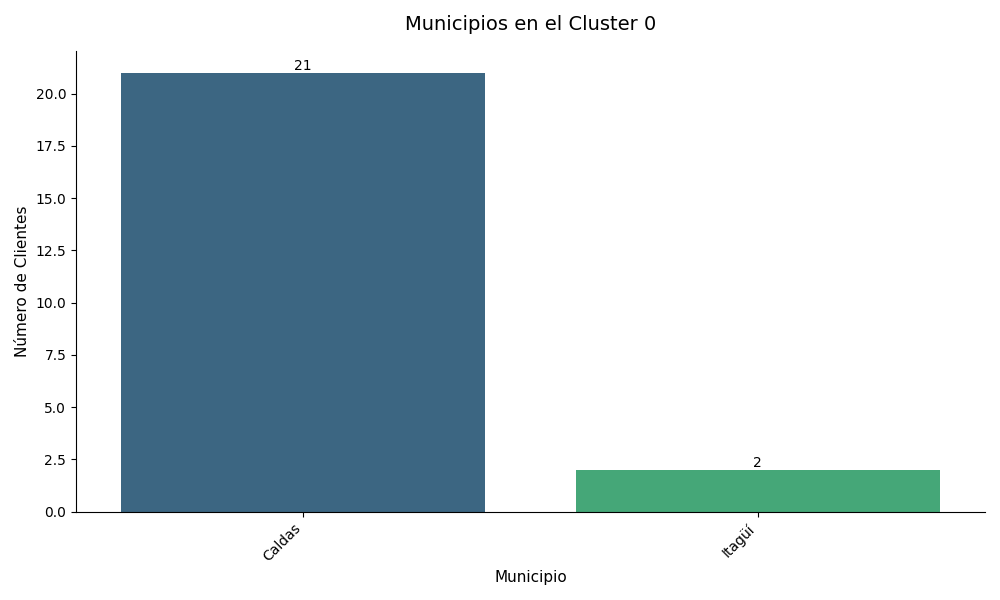
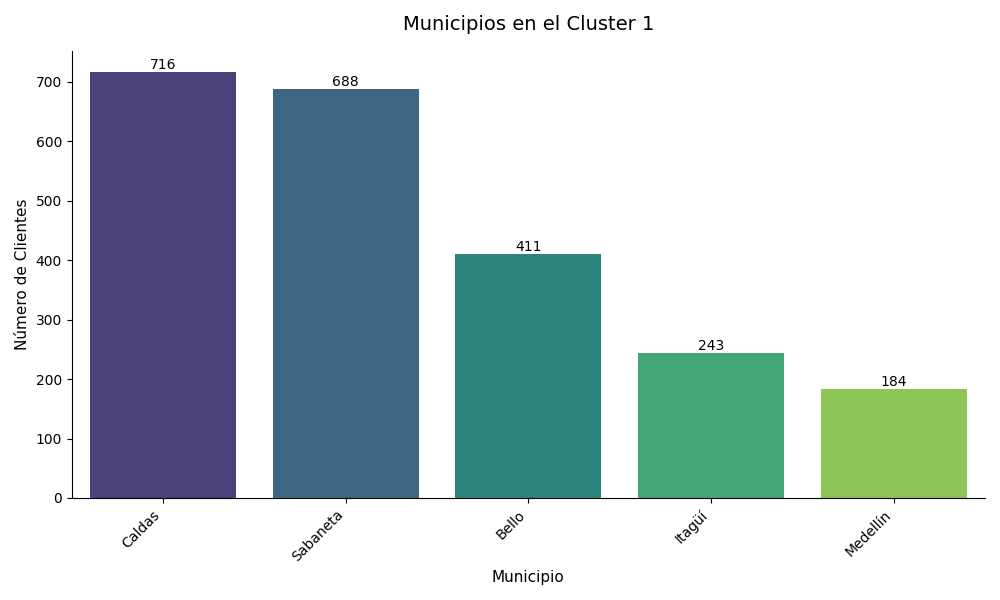
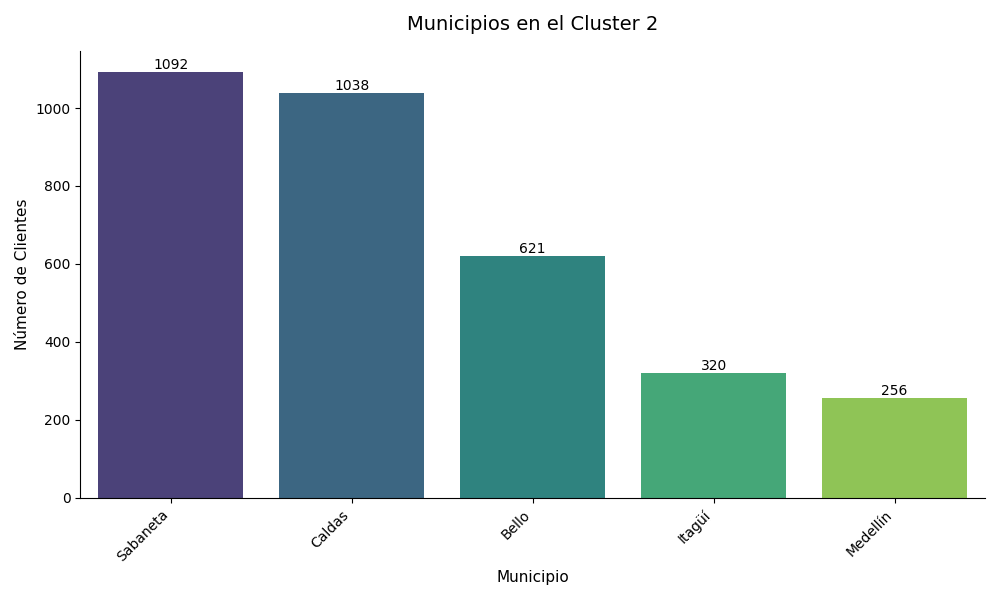
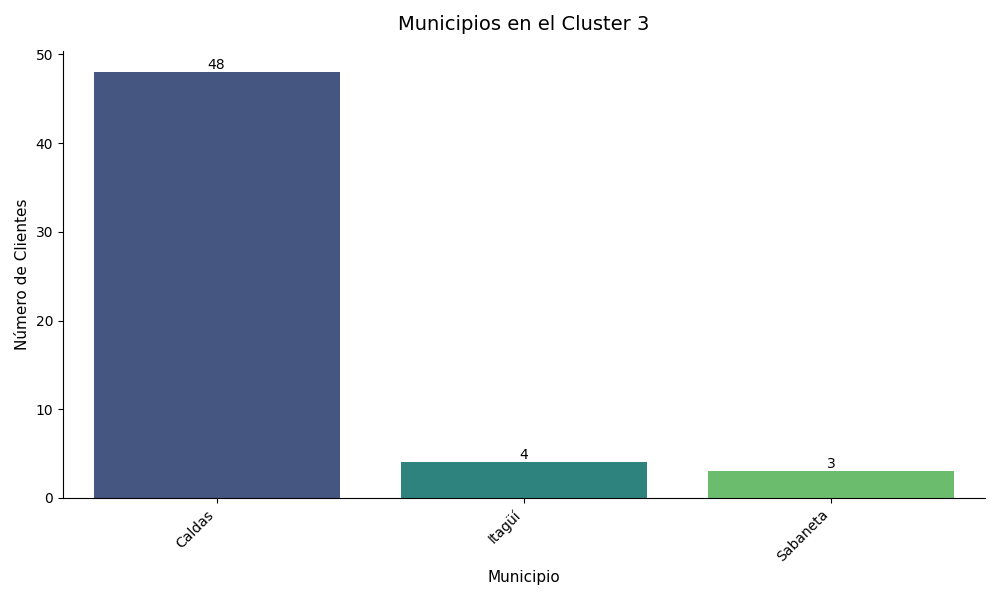
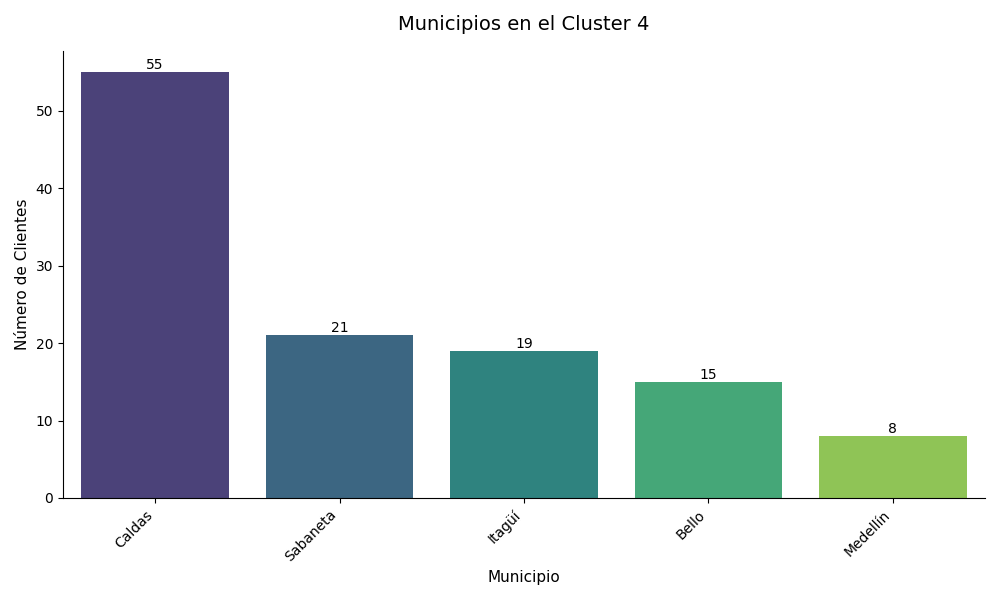

In [ ]:
import base64

# 🔹 Función para convertir imágenes
def convertir_imagen(ruta):
    with open(ruta, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# 🔹 Convertir imágenes principales
img_perfil = convertir_imagen("Perfil.png")
img_clientes = convertir_imagen("Clientes.png")
img_decision = convertir_imagen("Decision.png")

# 🔹 Convertir imágenes de municipios por cluster
imagenes_municipios = ""
for cluster_id in sorted(XDB['Cluster'].unique()):
    ruta = f"Municipios_Cluster_{int(cluster_id)}.png"
    try:
        img = convertir_imagen(ruta)
        imagenes_municipios += f"""
        <h3>Cluster {int(cluster_id)}</h3>
        <img src="data:image/png;base64,{img}">
        """
    except:
        pass  # Si alguna imagen no existe, la ignora

# 🔹 Tabla
tabla_html = cluster_stats_mean.round(2).to_html(index=False)

# 🔹 HTML completo
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Reporte de Clustering - Créditos</title>
    <style>
        body {{ font-family: Arial; margin: 30px; background-color: #f4f6f7; }}
        h1 {{ text-align: center; color: #2c3e50; }}
        h2 {{ color: #34495e; margin-top: 40px; }}
        h3 {{ color: #7f8c8d; }}
        table {{ width: 100%; border-collapse: collapse; margin-bottom: 30px; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: center; }}
        th {{ background-color: #2c3e50; color: white; }}
        img {{ max-width: 70%; margin: 20px auto; display: block; border-radius: 10px; }}
    </style>
</head>
<body>

<h1>Optimización de Asignación de Créditos</h1>

<h2>📊 Resultados Generales</h2>
{tabla_html}

<h2>🧠 Perfil de Clusters</h2>
<img src="data:image/png;base64,{img_perfil}">

<h2>👥 Número de Clientes por Cluster</h2>
<img src="data:image/png;base64,{img_clientes}">

<h2>📈 Preaprobación vs Prenegación</h2>
<img src="data:image/png;base64,{img_decision}">

<h2>🌍 Distribución de Municipios por Cluster</h2>
{imagenes_municipios}

<h2>📌 Conclusión</h2>
<p>
Los clusters identificados permiten segmentar a los clientes según su perfil financiero y geográfico,
facilitando la toma de decisiones estratégicas en la asignación de créditos y la optimización de sucursales.
</p>

</body>
</html>
"""

# 🔹 Guardar archivo
with open("index.html", "w") as f:
    f.write(html_content)

print("✅ Página web creada correctamente")

from IPython.display import display, HTML
display(HTML(html_content))

In [ ]:
import base64
import requests

token = 'token' #token from github here
repo = 'tgp989/integracionMultidimensionalFintech'
headers = {'Authorization': f"token {token}"}

# 🔹 Función para subir archivos
def upload_file(local_path, repo_path):
    print(f"Subiendo: {local_path} → {repo_path}")

    with open(local_path, "rb") as f:
        content = f.read()

    encoded = base64.b64encode(content).decode("utf-8")
    url = f"https://api.github.com/repos/{repo}/contents/{repo_path}"

    # Verificar si existe
    r = requests.get(url, headers=headers)

    if r.status_code == 200:
        sha = r.json()["sha"]
        data = {
            "message": f"Actualizando {repo_path}",
            "content": encoded,
            "sha": sha
        }
    else:
        data = {
            "message": f"Creando {repo_path}",
            "content": encoded
        }

    # Subir archivo
    r2 = requests.put(url, json=data, headers=headers)

    print("Estado:", r2.status_code)
    print("-----------------------------------")


# 🔹 Subir archivos principales
upload_file("index.html", "index.html")
upload_file("Perfil.png", "Perfil.png")
upload_file("Clientes.png", "Clientes.png")
upload_file("Decision.png", "Decision.png")

# 🔹 Subir automáticamente los municipios por cluster
for cluster_id in sorted(XDB['Cluster'].unique()):
    archivo = f"Municipios_Cluster_{int(cluster_id)}.png"
    try:
        upload_file(archivo, archivo)
    except:
        print(f"No se encontró {archivo}")

Subiendo: index.html → index.html
Estado: 200
-----------------------------------
Subiendo: Perfil.png → Perfil.png
Estado: 200
-----------------------------------
Subiendo: Clientes.png → Clientes.png
Estado: 200
-----------------------------------
Subiendo: Decision.png → Decision.png
Estado: 200
-----------------------------------
Subiendo: Municipios_Cluster_0.png → Municipios_Cluster_0.png
Estado: 200
-----------------------------------
Subiendo: Municipios_Cluster_1.png → Municipios_Cluster_1.png
Estado: 200
-----------------------------------
Subiendo: Municipios_Cluster_2.png → Municipios_Cluster_2.png
Estado: 200
-----------------------------------
Subiendo: Municipios_Cluster_3.png → Municipios_Cluster_3.png
Estado: 200
-----------------------------------
Subiendo: Municipios_Cluster_4.png → Municipios_Cluster_4.png
Estado: 200
-----------------------------------
